In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score, KFold
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LinearRegression, Ridge, Lasso
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics           import mean_squared_error, mean_absolute_error, r2_score
from xgboost                   import XGBRegressor
from lightgbm                  import LGBMRegressor

In [3]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#f8f9fa',
    'axes.grid'      : True,
    'grid.color'     : 'white',
    'grid.linewidth' : 1.2,
    'font.family'    : 'DejaVu Sans',
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#4361ee','#f72585','#4cc9f0','#7209b7','#fb8500',
           '#2dc653','#e63946','#adb5bd','#ff9f1c','#2ec4b6']

In [8]:
# 1. LOAD & CLEAN
df = pd.read_csv('../data/processed/tmdb_movies_clean_csv/tmdb_movies_clean.csv',
                 engine='python', on_bad_lines='skip')

# Numeric conversions
for col in ['Duration', 'TMDB Rating', 'Votes', 'Popularity', 'Year']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Grossed in $'] = pd.to_numeric(df['Grossed in $'], errors='coerce')

# Buang fill-value (nilai placeholder 21,760,713 yang muncul 54% baris)
FILL_VAL = 21_760_713.0
df['target_gross'] = df['Grossed in $'].apply(
    lambda x: x if (pd.notna(x) and x != FILL_VAL and x > 1_000) else np.nan
)

# Clean Certificate
valid_certs = ['G','PG','PG-13','R','NC-17','NR']
df['Certificate'] = df['Certificate'].where(df['Certificate'].isin(valid_certs), 'Unknown')

# Drop baris tanpa target & fitur penting
df = df.dropna(subset=['target_gross','TMDB Rating','Votes',
                        'Duration','Popularity','Genre',
                        'Original Language','Year'])
df = df[df['Genre'].str.match(r'^[A-Za-z, /]+$', na=False)]
df = df.reset_index(drop=True)

In [ ]:
# 2. TARGET TRANSFORM & FEATURE ENGINEERING
# Target: log1p(gross) agar distribusi normal
df['log_gross'] = np.log1p(df['target_gross'])

# Genre one-hot 
MAIN_GENRES = ['Action','Adventure','Animation','Comedy','Crime',
               'Documentary','Drama','Family','Fantasy','History',
               'Horror','Music','Mystery','Romance','Science Fiction',
               'Thriller','War','Western']
for g in MAIN_GENRES:
    df[f'genre_{g.replace(" ","_")}'] = df['Genre'].apply(lambda x: 1 if g in str(x) else 0)

df['genre_count'] = df['Genre'].apply(lambda x: len(str(x).split(',')))

# Language 
top_langs = df['Original Language'].value_counts().head(8).index.tolist()
for lang in top_langs:
    df[f'lang_{lang}'] = (df['Original Language'] == lang).astype(int)

# Certificate ordinal 
cert_map = {'G':1,'PG':2,'PG-13':3,'R':4,'NC-17':5,'NR':3,'Unknown':3}
df['cert_num'] = df['Certificate'].map(cert_map)

# Numeric transforms 
df['log_votes']      = np.log1p(df['Votes'])
df['log_popularity'] = np.log1p(df['Popularity'])
df['year_norm']      = (df['Year'] - df['Year'].mean()) / df['Year'].std()
df['duration_sq']    = df['Duration'] ** 2          # non-linear durasi
df['rating_votes']   = df['TMDB Rating'] * df['log_votes']  # interaksi

# Build feature matrix 
genre_cols = [f'genre_{g.replace(" ","_")}' for g in MAIN_GENRES] + ['genre_count']
lang_cols  = [f'lang_{l}' for l in top_langs]
num_cols   = ['TMDB Rating','log_votes','Duration','duration_sq',
              'log_popularity','cert_num','year_norm','rating_votes']

feature_cols = num_cols + genre_cols + lang_cols
X = df[feature_cols].values
y = df['log_gross'].values

In [10]:
# 3. SPLIT & SCALE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"  → Train: {len(X_train):,}   Test: {len(X_test):,}")

  → Train: 6,808   Test: 1,703


In [11]:
# 4. TRAIN SEMUA 
models = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=10.0),
    'Random Forest'    : RandomForestRegressor(
                            n_estimators=200, max_depth=12,
                            min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
                            n_estimators=300, learning_rate=0.05,
                            max_depth=5, subsample=0.8, random_state=42),
    'XGBoost'          : XGBRegressor(
                            n_estimators=300, learning_rate=0.05,
                            max_depth=6, subsample=0.8,
                            colsample_bytree=0.8, random_state=42,
                            verbosity=0, n_jobs=-1),
    'LightGBM'         : LGBMRegressor(
                            n_estimators=300, learning_rate=0.05,
                            max_depth=6, subsample=0.8,
                            colsample_bytree=0.8, random_state=42,
                            verbose=-1, n_jobs=-1),
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Gunakan scaled data untuk linear models, raw untuk tree-based
    is_linear = name in ('Linear Regression','Ridge','Lasso')
    Xtr = X_train_s if is_linear else X_train
    Xte = X_test_s  if is_linear else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # RMSE di skala asli (dollar)
    rmse_dollar = np.sqrt(mean_squared_error(
        np.expm1(y_test), np.expm1(y_pred)))

    # CV score
    cv_r2 = cross_val_score(model, Xtr, y_train,
                            cv=kf, scoring='r2', n_jobs=-1).mean()

    results[name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'rmse_log'    : rmse,
        'mae_log'     : mae,
        'r2'          : r2,
        'rmse_dollar' : rmse_dollar,
        'cv_r2'       : cv_r2,
    }
    print(f"  {name:<22} R²={r2:.4f}  RMSE(log)={rmse:.4f}  CV-R²={cv_r2:.4f}")

best_name = max(results, key=lambda k: results[k]['r2'])
print(f"\nModel terbaik: {best_name}  (R²={results[best_name]['r2']:.4f})")


  Linear Regression      R²=0.4820  RMSE(log)=1.6806  CV-R²=0.4778
  Ridge                  R²=0.4826  RMSE(log)=1.6796  CV-R²=0.4776
  Random Forest          R²=0.5839  RMSE(log)=1.5062  CV-R²=0.5774
  Gradient Boosting      R²=0.6199  RMSE(log)=1.4395  CV-R²=0.5993
  XGBoost                R²=0.6168  RMSE(log)=1.4455  CV-R²=0.5981
  LightGBM               R²=0.6130  RMSE(log)=1.4527  CV-R²=0.6006

Model terbaik: Gradient Boosting  (R²=0.6199)


In [12]:
%matplotlib inline

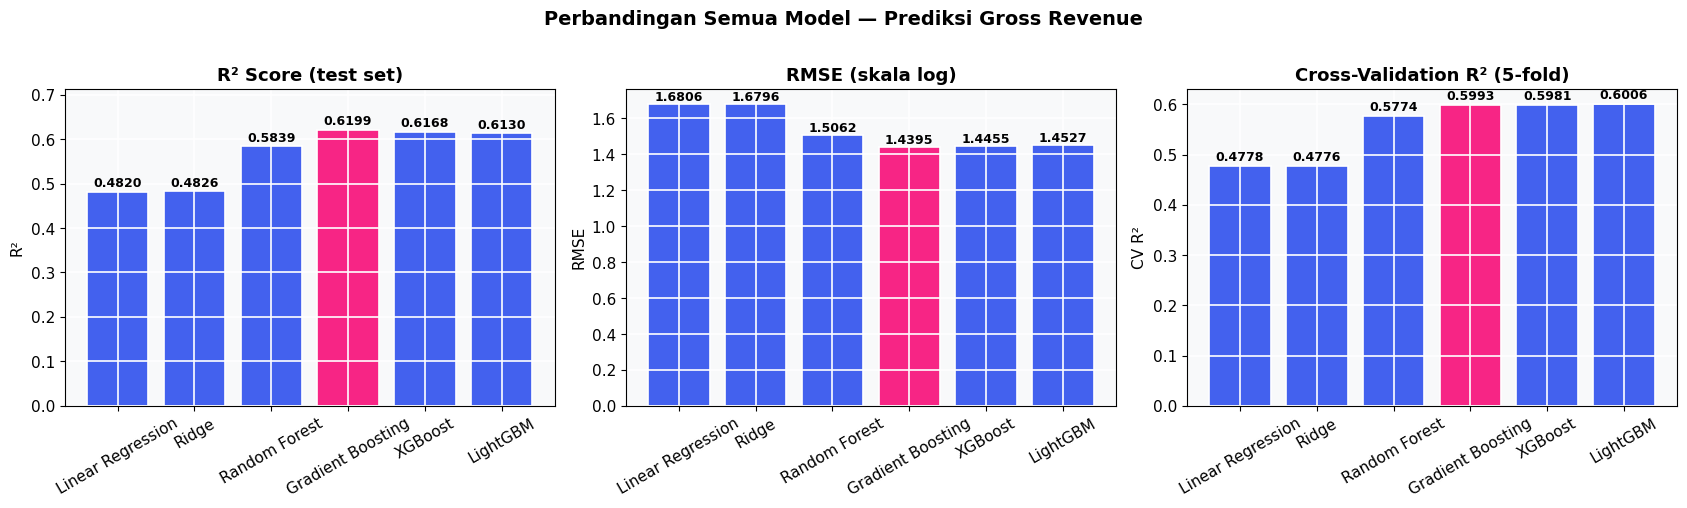

In [ ]:
# 5. VISUALISASI
# Fig 1: Model comparison metrics 
fig1, axes = plt.subplots(1, 3, figsize=(17, 5))
fig1.suptitle('Perbandingan Semua Model — Prediksi Gross Revenue',
              fontsize=14, fontweight='bold', y=1.01)

names  = list(results.keys())
r2s    = [results[n]['r2']      for n in names]
rmses  = [results[n]['rmse_log'] for n in names]
cv_r2s = [results[n]['cv_r2']   for n in names]
colors = [('#f72585' if n == best_name else '#4361ee') for n in names]

# R² bar
bars = axes[0].bar(names, r2s, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, r2s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('R² Score (test set)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, max(r2s) * 1.15)
axes[0].tick_params(axis='x', rotation=30)

# RMSE bar
bars2 = axes[1].bar(names, rmses, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('RMSE (skala log)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)

# CV R² bar
bars3 = axes[2].bar(names, cv_r2s, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars3, cv_r2s):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_title('Cross-Validation R² (5-fold)')
axes[2].set_ylabel('CV R²')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

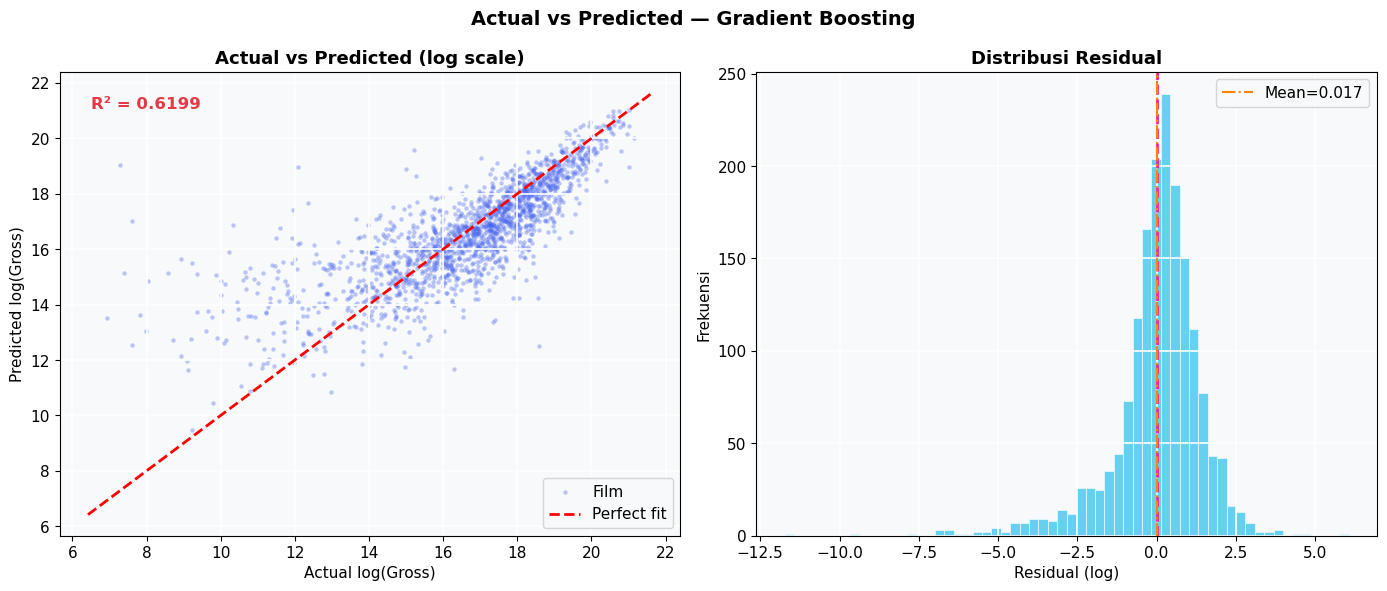

In [ ]:
# Fig 2: Actual vs Predicted (best model) 
best_pred = results[best_name]['y_pred']

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle(f'Actual vs Predicted — {best_name}', fontsize=14, fontweight='bold')

# Scatter actual vs predicted (log scale)
axes2[0].scatter(y_test, best_pred, alpha=0.35, s=10,
                 color='#4361ee', linewidths=0, label='Film')
lims = [min(y_test.min(), best_pred.min()) - 0.5,
        max(y_test.max(), best_pred.max()) + 0.5]
axes2[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
axes2[0].set_xlabel('Actual log(Gross)')
axes2[0].set_ylabel('Predicted log(Gross)')
axes2[0].set_title('Actual vs Predicted (log scale)')
axes2[0].legend()
axes2[0].text(0.05, 0.92, f'R² = {results[best_name]["r2"]:.4f}',
              transform=axes2[0].transAxes, fontsize=12, fontweight='bold',
              color='#e63946')

# Residual distribution
residuals = y_test - best_pred
axes2[1].hist(residuals, bins=60, color='#4cc9f0', edgecolor='white',
              linewidth=0.5, alpha=0.85)
axes2[1].axvline(0, color='#f72585', linestyle='--', linewidth=2)
axes2[1].axvline(residuals.mean(), color='#fb8500', linestyle='-.',
                 linewidth=1.5, label=f'Mean={residuals.mean():.3f}')
axes2[1].set_title('Distribusi Residual')
axes2[1].set_xlabel('Residual (log)')
axes2[1].set_ylabel('Frekuensi')
axes2[1].legend()

plt.tight_layout()
plt.show()

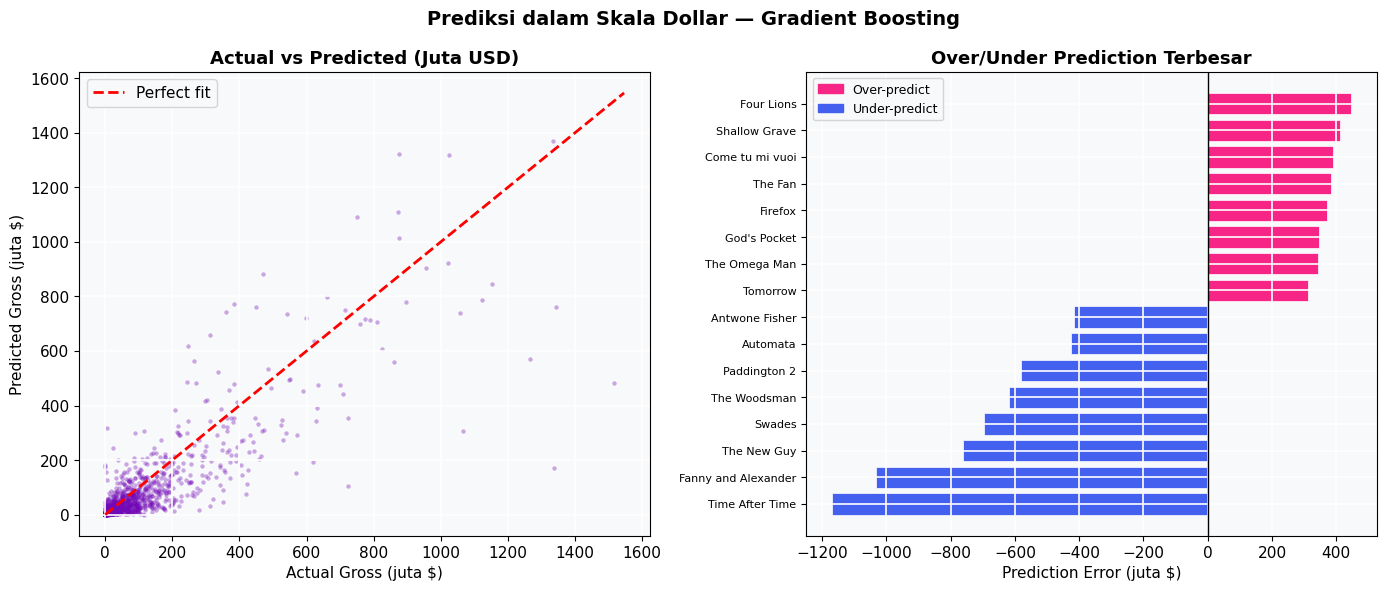

In [ ]:
# Fig 3: Actual vs Predicted DOLLAR scale 
actual_dollar = np.expm1(y_test) / 1e6
pred_dollar   = np.expm1(best_pred) / 1e6

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle(f'Prediksi dalam Skala Dollar — {best_name}', fontsize=14, fontweight='bold')

# Scatter dollar
axes3[0].scatter(actual_dollar, pred_dollar, alpha=0.35, s=10,
                 color='#7209b7', linewidths=0)
lim_d = [0, max(actual_dollar.max(), pred_dollar.max()) * 1.02]
axes3[0].plot(lim_d, lim_d, 'r--', linewidth=2, label='Perfect fit')
axes3[0].set_xlabel('Actual Gross (juta $)')
axes3[0].set_ylabel('Predicted Gross (juta $)')
axes3[0].set_title('Actual vs Predicted (Juta USD)')
axes3[0].legend()

# Top over/under predictions
df_test_eval = pd.DataFrame({
    'movie'  : df.iloc[
        [i for i in range(len(df)) if i in
         np.where(np.isin(df['log_gross'].values, y_test))[0]]
    ]['Movie Name'].values[:len(y_test)],
    'actual' : actual_dollar,
    'pred'   : pred_dollar,
    'error'  : pred_dollar - actual_dollar,
})
df_test_eval = df_test_eval.sort_values('error')
top_under = df_test_eval.head(8)
top_over  = df_test_eval.tail(8)

combined = pd.concat([top_under, top_over])
bar_colors = ['#f72585' if e > 0 else '#4361ee' for e in combined['error']]
axes3[1].barh(range(len(combined)), combined['error'],
              color=bar_colors, edgecolor='white', linewidth=0.5)
axes3[1].set_yticks(range(len(combined)))
axes3[1].set_yticklabels(
    [m[:28] for m in combined['movie']], fontsize=8)
axes3[1].axvline(0, color='black', linewidth=1)
axes3[1].set_xlabel('Prediction Error (juta $)')
axes3[1].set_title('Over/Under Prediction Terbesar')
from matplotlib.patches import Patch
axes3[1].legend(handles=[Patch(color='#f72585', label='Over-predict'),
                          Patch(color='#4361ee', label='Under-predict')],
                fontsize=9)

plt.tight_layout()
plt.show()

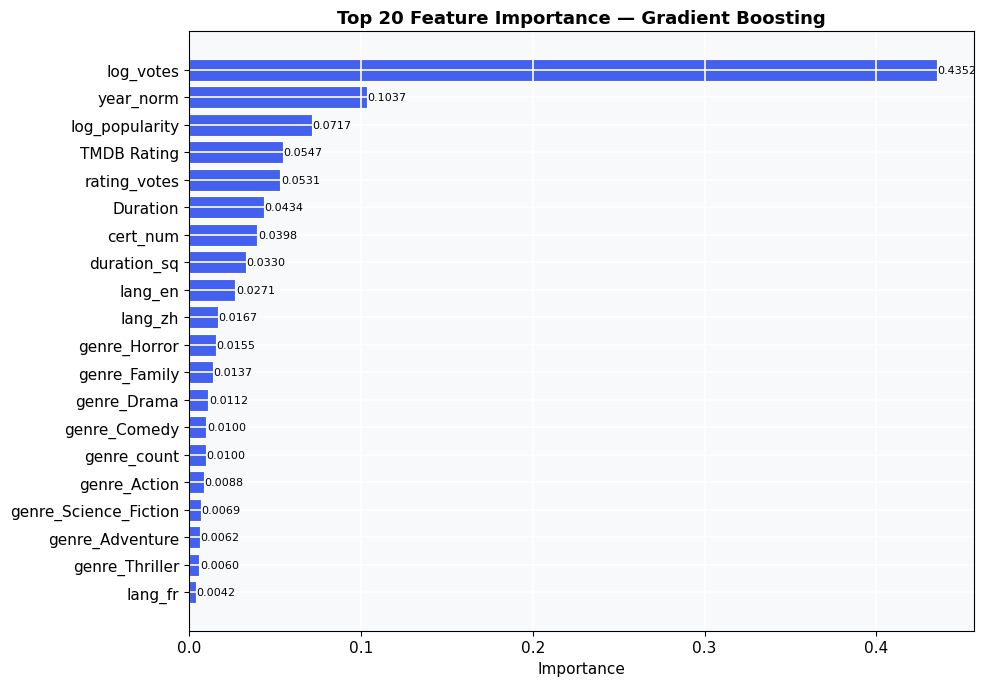

In [ ]:
# Fig 4: Feature Importance 
# Menggunakan model tree-based terbaik untuk feature importance
tree_models = {k: v for k, v in results.items()
               if k not in ('Linear Regression','Ridge')}
best_tree_name = max(tree_models, key=lambda k: tree_models[k]['r2'])
best_tree = results[best_tree_name]['model']

if hasattr(best_tree, 'feature_importances_'):
    importances = best_tree.feature_importances_
    fi_df = pd.DataFrame({
        'feature'   : feature_cols,
        'importance': importances,
    }).sort_values('importance', ascending=False).head(20)

    fig4, ax4 = plt.subplots(figsize=(10, 7))
    bars4 = ax4.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
                     color='#4361ee', edgecolor='white', linewidth=0.8)
    ax4.set_title(f'Top 20 Feature Importance — {best_tree_name}',
                  fontsize=13, fontweight='bold')
    ax4.set_xlabel('Importance')
    for bar, val in zip(bars4, fi_df['importance'][::-1]):
        ax4.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

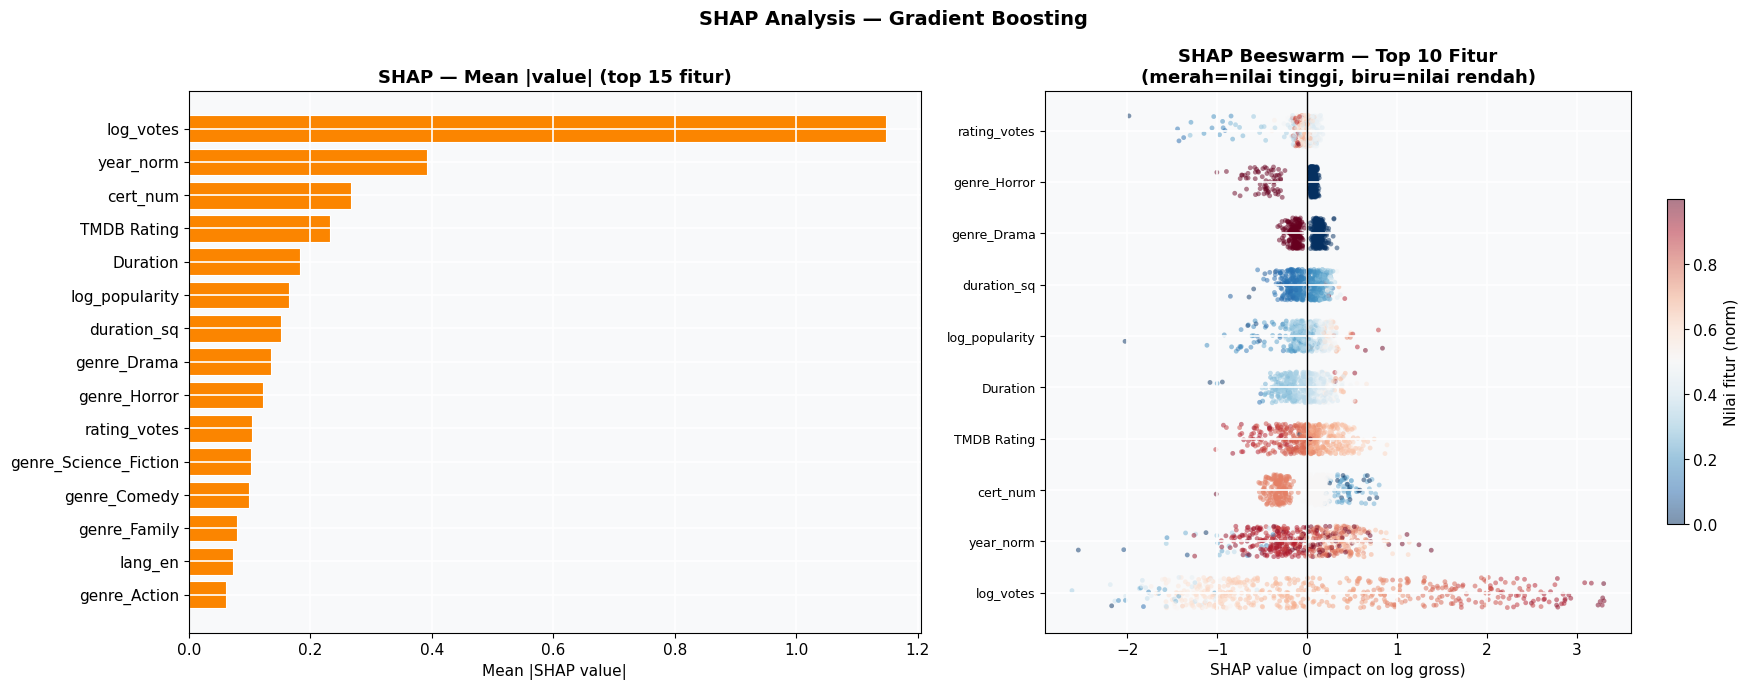

In [ ]:
# Fig 5: SHAP values (best tree model)
X_shap_sample = X_test[:500]   # sample 500 baris agar cepat

try:
    explainer  = shap.TreeExplainer(best_tree)
    shap_vals  = explainer.shap_values(X_shap_sample)

    fig5, axes5 = plt.subplots(1, 2, figsize=(18, 7))
    fig5.suptitle(f'SHAP Analysis — {best_tree_name}',
                  fontsize=14, fontweight='bold')

    # SHAP summary bar
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    shap_df = pd.DataFrame({
        'feature': feature_cols,
        'mean_abs_shap': mean_abs_shap,
    }).sort_values('mean_abs_shap', ascending=False).head(15)

    axes5[0].barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1],
                  color='#fb8500', edgecolor='white', linewidth=0.8)
    axes5[0].set_title('SHAP — Mean |value| (top 15 fitur)')
    axes5[0].set_xlabel('Mean |SHAP value|')

    # SHAP beeswarm manual (scatter per top feature)
    top_features = shap_df['feature'].head(10).tolist()
    top_indices  = [feature_cols.index(f) for f in top_features]

    y_pos = np.arange(len(top_features))
    for i, (feat_idx, feat_name) in enumerate(zip(top_indices, top_features)):
        shap_col = shap_vals[:, feat_idx]
        feat_col = X_shap_sample[:, feat_idx]
        # Normalize feat color
        vmin, vmax = feat_col.min(), feat_col.max()
        norm_feat = (feat_col - vmin) / (vmax - vmin + 1e-8)
        jitter = np.random.uniform(-0.3, 0.3, len(shap_col))
        sc = axes5[1].scatter(
            shap_col, np.full_like(shap_col, i) + jitter,
            c=norm_feat, cmap='RdBu_r', alpha=0.5, s=12, linewidths=0)

    axes5[1].set_yticks(y_pos)
    axes5[1].set_yticklabels(top_features, fontsize=9)
    axes5[1].axvline(0, color='black', linewidth=1)
    axes5[1].set_xlabel('SHAP value (impact on log gross)')
    axes5[1].set_title('SHAP Beeswarm — Top 10 Fitur\n(merah=nilai tinggi, biru=nilai rendah)')
    plt.colorbar(sc, ax=axes5[1], label='Nilai fitur (norm)', shrink=0.6)
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"SHAP skipped: {e}")


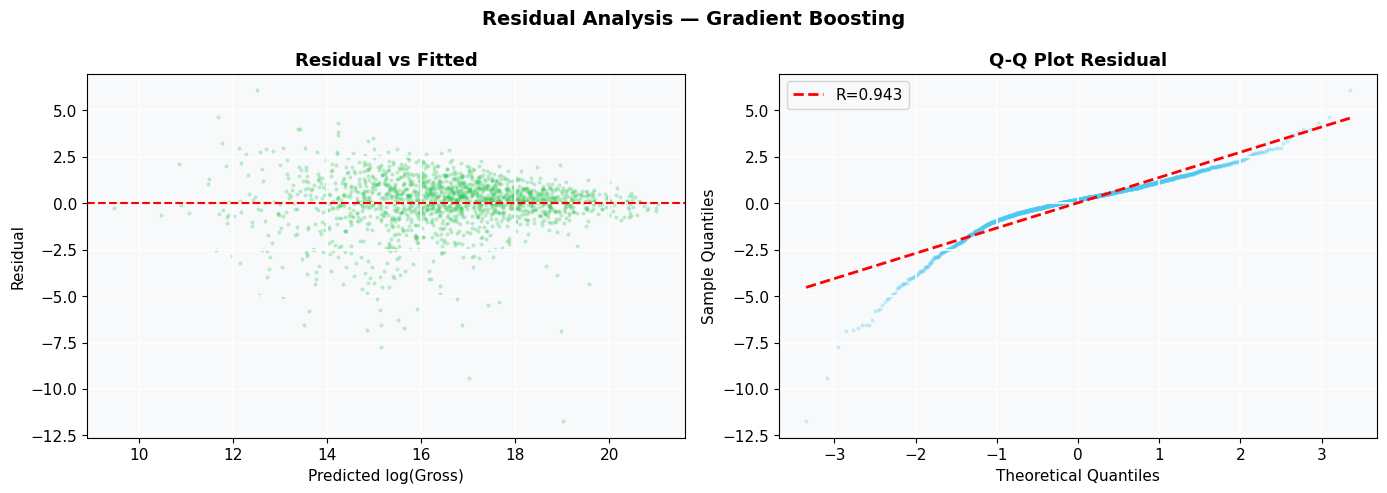

In [ ]:
# Fig 6: Residual vs predicted + QQ
fig6, axes6 = plt.subplots(1, 2, figsize=(14, 5))
fig6.suptitle(f'Residual Analysis — {best_name}',
              fontsize=14, fontweight='bold')

# Residual vs fitted
axes6[0].scatter(best_pred, residuals, alpha=0.3, s=8,
                 color='#2dc653', linewidths=0)
axes6[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes6[0].set_xlabel('Predicted log(Gross)')
axes6[0].set_ylabel('Residual')
axes6[0].set_title('Residual vs Fitted')

# QQ plot (normal probability)
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes6[1].scatter(osm, osr, alpha=0.3, s=8, color='#4cc9f0', linewidths=0)
axes6[1].plot(osm, slope * np.array(osm) + intercept,
              'r--', linewidth=2, label=f'R={r:.3f}')
axes6[1].set_xlabel('Theoretical Quantiles')
axes6[1].set_ylabel('Sample Quantiles')
axes6[1].set_title('Q-Q Plot Residual')
axes6[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 7. RINGKASAN & CONTOH PREDIKSI
print("\n" + "=" * 65)
print("  HASIL EVALUASI SEMUA MODEL")
print("=" * 65)
print(f"  {'Model':<22} {'R²':>8} {'RMSE(log)':>10} {'CV R²':>8}  {'RMSE ($M)':>10}")
print(f"  {'-'*62}")
for name, r in sorted(results.items(), key=lambda x: -x[1]['r2']):
    marker = ' ★' if name == best_name else '  '
    print(f"{marker} {name:<22} {r['r2']:>8.4f} {r['rmse_log']:>10.4f} "
          f"{r['cv_r2']:>8.4f}  {r['rmse_dollar']/1e6:>9.1f}M")

print(f"\n  Best model  : {best_name}")
print(f"  R²          : {results[best_name]['r2']:.4f}")
print(f"  RMSE (log)  : {results[best_name]['rmse_log']:.4f}")
print(f"  CV R²       : {results[best_name]['cv_r2']:.4f}")
print(f"  RMSE ($)    : ${results[best_name]['rmse_dollar']/1e6:.1f}M")


  HASIL EVALUASI SEMUA MODEL
  Model                        R²  RMSE(log)    CV R²   RMSE ($M)
  --------------------------------------------------------------
 ★ Gradient Boosting        0.6199     1.4395   0.5993       84.5M
   XGBoost                  0.6168     1.4455   0.5981       83.8M
   LightGBM                 0.6130     1.4527   0.6006       84.8M
   Random Forest            0.5839     1.5062   0.5774       84.5M
   Ridge                    0.4826     1.6796   0.4776      105.7M
   Linear Regression        0.4820     1.6806   0.4778      105.9M

  Best model  : Gradient Boosting
  R²          : 0.6199
  RMSE (log)  : 1.4395
  CV R²       : 0.5993
  RMSE ($)    : $84.5M


In [ ]:
# Contoh prediksi film baru
print("─" * 65)
print("  CONTOH PREDIKSI FILM BARU")
print("─" * 65)

def predict_revenue(movie_info: dict) -> float:
    """
    Prediksi gross revenue sebuah film baru.
    movie_info keys: rating, votes, duration, popularity, year,
                     certificate, genres (list), language
    """
    row = np.zeros(len(feature_cols))
    col_idx = {c: i for i, c in enumerate(feature_cols)}

    row[col_idx['TMDB Rating']]    = movie_info.get('rating', 7.0)
    row[col_idx['log_votes']]      = np.log1p(movie_info.get('votes', 1000))
    row[col_idx['Duration']]       = movie_info.get('duration', 110)
    row[col_idx['duration_sq']]    = movie_info.get('duration', 110) ** 2
    row[col_idx['log_popularity']] = np.log1p(movie_info.get('popularity', 5))
    row[col_idx['cert_num']]       = cert_map.get(movie_info.get('certificate','PG-13'), 3)
    row[col_idx['year_norm']]      = (movie_info.get('year', 2024) - df['Year'].mean()) / df['Year'].std()
    row[col_idx['rating_votes']]   = (movie_info.get('rating', 7.0) *
                                      np.log1p(movie_info.get('votes', 1000)))

    for g in movie_info.get('genres', []):
        key = f'genre_{g.replace(" ","_")}'
        if key in col_idx:
            row[col_idx[key]] = 1
    row[col_idx['genre_count']] = len(movie_info.get('genres', []))

    lang_key = f'lang_{movie_info.get("language","en")}'
    if lang_key in col_idx:
        row[col_idx[lang_key]] = 1

    log_pred = results[best_name]['model'].predict(row.reshape(1, -1))[0]
    return np.expm1(log_pred)

sample_movies = [
    {
        'name'       : 'Avengers-style blockbuster',
        'rating'     : 8.0, 'votes': 50000, 'duration': 150,
        'popularity' : 80, 'year': 2025, 'certificate': 'PG-13',
        'genres'     : ['Action','Adventure','Science Fiction'],
        'language'   : 'en',
    },
    {
        'name'       : 'Indie Drama',
        'rating'     : 7.5, 'votes': 800, 'duration': 100,
        'popularity' : 3, 'year': 2024, 'certificate': 'R',
        'genres'     : ['Drama'],
        'language'   : 'en',
    },
    {
        'name'       : 'Anime feature',
        'rating'     : 8.5, 'votes': 10000, 'duration': 120,
        'popularity' : 30, 'year': 2025, 'certificate': 'PG',
        'genres'     : ['Animation','Fantasy','Adventure'],
        'language'   : 'ja',
    },
    {
        'name'       : 'Family comedy',
        'rating'     : 6.5, 'votes': 5000, 'duration': 95,
        'popularity' : 15, 'year': 2025, 'certificate': 'PG',
        'genres'     : ['Comedy','Family'],
        'language'   : 'en',
    },
]

for m in sample_movies:
    pred = predict_revenue(m)
    print(f"  {m['name']:<35} → ${pred:>15,.0f}")

─────────────────────────────────────────────────────────────────
  CONTOH PREDIKSI FILM BARU
─────────────────────────────────────────────────────────────────
  Avengers-style blockbuster          → $  4,567,091,744
  Indie Drama                         → $      5,090,667
  Anime feature                       → $    998,422,225
  Family comedy                       → $  1,139,515,804
